# Synthetic Low-Light Dataset Preparation for ALICE

This notebook builds a full data preparation pipeline for the `data/Eights` dataset.

It will:

1. collect RGB images from all `ZM-Baseline-*` folders
2. generate synthetic low-light RGB and monochrome pairs
3. split the data into `90%` train and `10%` test
4. save the output in an ALICE-compatible structure under `data/processed/`

Output structure:

```text
data/processed/
├── train/
│   ├── rgb_low/
│   ├── mono_low/
│   └── gt/
└── test/
    ├── rgb_low/
    ├── mono_low/
    └── gt/
```

In [33]:
# 1. Imports

from pathlib import Path
import random
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

In [34]:
# 2. Config (paths, seed, split ratio)

SEED = 47
TRAIN_RATIO = 0.9
IMAGE_SIZE = 256
MAX_SAMPLES = 600  # keep the dataset in the 200-500 range for fast experimentation
RESET_OUTPUT = True
VALID_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}


def resolve_existing_path(*candidates: str) -> Path:
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f'None of the candidate paths exist: {candidates}')


DATA_ROOT = resolve_existing_path('data/eights', 'data/Eights')
OUTPUT_ROOT = Path('data/processed')
TRAIN_ROOT = OUTPUT_ROOT / 'train'
TEST_ROOT = OUTPUT_ROOT / 'test'

print(f'Data root: {DATA_ROOT.resolve()}')
print(f'Output root: {OUTPUT_ROOT.resolve()}')
print(f'Seed: {SEED}')
print(f'Train ratio: {TRAIN_RATIO}')
print(f'Max samples: {MAX_SAMPLES}')

Data root: H:\image_processing\ALICEO\data\Eights
Output root: H:\image_processing\ALICEO\data\processed
Seed: 47
Train ratio: 0.9
Max samples: 600


## Why Synthetic Degradation Is Needed

Real paired low-light aerial datasets are often difficult to collect because they require synchronized capture, consistent camera geometry, and clean ground-truth targets. Synthetic degradation is a practical way to create supervised training data from normal images.

Each degradation stage simulates a common low-light artifact:

- **brightness reduction** simulates under-exposure
- **gamma correction** darkens mid-tones and shadows more aggressively
- **Gaussian noise** simulates sensor and read noise
- **color shift** simulates channel imbalance and color instability in low light
- **optional blur** simulates motion blur or low-SNR smoothing

The resulting dataset is not a perfect substitute for real low-light data, but it is very useful for model debugging, training-pipeline validation, and rapid experimentation.

In [35]:
# 3. Data collection


def collect_image_paths(data_root: Path) -> list[Path]:
    image_paths: list[Path] = []
    baseline_dirs = sorted(path for path in data_root.glob('ZM-Baseline-*') if path.is_dir())

    for baseline_dir in baseline_dirs:
        for image_dir_name in ('ImageLeft', 'ImageRight'):
            image_dir = baseline_dir / image_dir_name
            if not image_dir.exists():
                continue

            for image_path in sorted(image_dir.rglob('*')):
                if image_path.is_file() and image_path.suffix.lower() in VALID_EXTENSIONS:
                    image_paths.append(image_path)

    return image_paths


all_image_paths = collect_image_paths(DATA_ROOT)
print(f'Total collected images before shuffle: {len(all_image_paths)}')

shuffle_rng = random.Random(SEED)
shuffle_rng.shuffle(all_image_paths)

if MAX_SAMPLES is not None:
    all_image_paths = all_image_paths[: min(MAX_SAMPLES, len(all_image_paths))]

print(f'Total images after capping: {len(all_image_paths)}')
print('First 5 samples:')
for sample_path in all_image_paths[:5]:
    print('  ', sample_path)

Total collected images before shuffle: 630
Total images after capping: 600
First 5 samples:
   data\eights\ZM-Baseline-30\ImageRight\0140_R.png
   data\eights\ZM-Baseline-22\ImageRight\0060_R.png
   data\eights\ZM-Baseline-15\ImageLeft\0110_L.png
   data\eights\ZM-Baseline-30\ImageLeft\0060_L.png
   data\eights\ZM-Baseline-18\ImageLeft\0090_L.png


In [36]:
# 4. Train-test split

if len(all_image_paths) < 2:
    raise RuntimeError('Need at least two images to create a 90/10 train-test split.')

train_count = int(len(all_image_paths) * TRAIN_RATIO)
train_count = min(max(train_count, 1), len(all_image_paths) - 1)
test_count = len(all_image_paths) - train_count

train_paths = all_image_paths[:train_count]
test_paths = all_image_paths[train_count:]

print(f'Train samples: {len(train_paths)}')
print(f'Test samples: {len(test_paths)}')

Train samples: 540
Test samples: 60


In [37]:
# 5. Degradation functions


def load_rgb_image(image_path: Path, image_size: int = IMAGE_SIZE) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f'Failed to load image: {image_path}')
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_rgb = cv2.resize(image_rgb, (image_size, image_size), interpolation=cv2.INTER_AREA)
    return image_rgb


def sample_degradation_params(rng: np.random.Generator) -> dict:
    use_blur = bool(rng.random() < 0.35)
    blur_kernel = int(rng.choice([3, 5])) if use_blur else 0
    blur_direction = str(rng.choice(['horizontal', 'vertical', 'diagonal'])) if use_blur else None

    return {
        'brightness_factor': float(rng.uniform(0.35, 0.75)),
        'gamma': float(rng.uniform(1.2, 2.2)),
        'gaussian_sigma': float(rng.uniform(0.01, 0.04)),
        'color_gain': rng.uniform(0.9, 1.1, size=3).astype(np.float32),
        'color_bias': rng.uniform(-0.03, 0.03, size=3).astype(np.float32),
        'blur_kernel': blur_kernel,
        'blur_direction': blur_direction,
    }


def apply_gamma(image_float: np.ndarray, gamma: float) -> np.ndarray:
    return np.power(np.clip(image_float, 0.0, 1.0), gamma)


def apply_motion_blur(image_float: np.ndarray, kernel_size: int, direction: str | None) -> np.ndarray:
    if kernel_size <= 1 or direction is None:
        return image_float

    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    if direction == 'horizontal':
        kernel[kernel_size // 2, :] = 1.0
    elif direction == 'vertical':
        kernel[:, kernel_size // 2] = 1.0
    else:
        np.fill_diagonal(kernel, 1.0)

    kernel /= max(kernel.sum(), 1e-8)
    return cv2.filter2D(image_float, -1, kernel)


def degrade_rgb(clean_rgb: np.ndarray, params: dict, rng: np.random.Generator) -> np.ndarray:
    image = clean_rgb.astype(np.float32) / 255.0
    image = image * params['brightness_factor']
    image = apply_gamma(image, params['gamma'])
    image = image * params['color_gain'].reshape(1, 1, 3) + params['color_bias'].reshape(1, 1, 3)
    image = apply_motion_blur(image, params['blur_kernel'], params['blur_direction'])
    noise = rng.normal(0.0, params['gaussian_sigma'], size=image.shape).astype(np.float32)
    image = image + noise
    image = np.clip(image, 0.0, 1.0)
    return (image * 255.0).round().astype(np.uint8)


def degrade_mono(clean_mono: np.ndarray, params: dict, rng: np.random.Generator) -> np.ndarray:
    image = clean_mono.astype(np.float32) / 255.0
    image = image * params['brightness_factor']
    image = apply_gamma(image, params['gamma'])
    image = apply_motion_blur(image, params['blur_kernel'], params['blur_direction'])
    noise = rng.normal(0.0, params['gaussian_sigma'], size=image.shape).astype(np.float32)
    image = image + noise
    image = np.clip(image, 0.0, 1.0)
    return (image * 255.0).round().astype(np.uint8)


def make_sample(image_path: Path, global_index: int) -> dict:
    clean_rgb = load_rgb_image(image_path, IMAGE_SIZE)
    clean_mono = cv2.cvtColor(clean_rgb, cv2.COLOR_RGB2GRAY)

    rgb_rng = np.random.default_rng(SEED + global_index)
    mono_rng = np.random.default_rng(SEED + 10_000 + global_index)
    params = sample_degradation_params(np.random.default_rng(SEED + 20_000 + global_index))

    rgb_low = degrade_rgb(clean_rgb, params, rgb_rng)
    mono_low = degrade_mono(clean_mono, params, mono_rng)

    return {
        'source_path': image_path,
        'gt': clean_rgb,
        'rgb_low': rgb_low,
        'mono_low': mono_low,
        'params': params,
    }

In [38]:
# 6. Saving dataset


def prepare_output_structure(output_root: Path, reset_output: bool = True) -> None:
    for split_name in ('train', 'test'):
        for subdir_name in ('rgb_low', 'mono_low', 'gt'):
            subdir = output_root / split_name / subdir_name
            subdir.mkdir(parents=True, exist_ok=True)

            if reset_output:
                for existing_file in subdir.glob('*.png'):
                    existing_file.unlink()


def save_rgb(path: Path, image_rgb: np.ndarray) -> None:
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), image_bgr)


def save_mono(path: Path, image_gray: np.ndarray) -> None:
    cv2.imwrite(str(path), image_gray)


def process_split(split_name: str, split_paths: list[Path], global_offset: int) -> list[str]:
    split_root = OUTPUT_ROOT / split_name
    saved_names: list[str] = []

    for local_index, image_path in tqdm(
        list(enumerate(split_paths, start=1)),
        total=len(split_paths),
        desc=f'Generating {split_name} split',
    ):
        global_index = global_offset + (local_index - 1)
        sample = make_sample(image_path, global_index)
        file_name = f'{local_index:04d}.png'

        save_rgb(split_root / 'rgb_low' / file_name, sample['rgb_low'])
        save_mono(split_root / 'mono_low' / file_name, sample['mono_low'])
        save_rgb(split_root / 'gt' / file_name, sample['gt'])
        saved_names.append(file_name)

    return saved_names


def verify_split_pairs(split_root: Path) -> None:
    rgb_names = sorted(path.name for path in (split_root / 'rgb_low').glob('*.png'))
    mono_names = sorted(path.name for path in (split_root / 'mono_low').glob('*.png'))
    gt_names = sorted(path.name for path in (split_root / 'gt').glob('*.png'))

    assert rgb_names == mono_names == gt_names, f'Mismatched files in {split_root}'
    print(f'{split_root.name}: verified {len(rgb_names)} matching triplets')

In [39]:
# 7. Dataset generation loop

prepare_output_structure(OUTPUT_ROOT, reset_output=RESET_OUTPUT)

train_names = process_split('train', train_paths, global_offset=0)
test_names = process_split('test', test_paths, global_offset=len(train_paths))

verify_split_pairs(TRAIN_ROOT)
verify_split_pairs(TEST_ROOT)

print('\nDataset generation complete.')
print(f'Train triplets saved: {len(train_names)}')
print(f'Test triplets saved: {len(test_names)}')
print(f'Processed dataset location: {OUTPUT_ROOT.resolve()}')

Generating test split: 100%|██████████| 60/60 [00:02<00:00, 27.02it/s]

train: verified 540 matching triplets
test: verified 60 matching triplets

Dataset generation complete.
Train triplets saved: 540
Test triplets saved: 60
Processed dataset location: H:\image_processing\ALICEO\data\processed


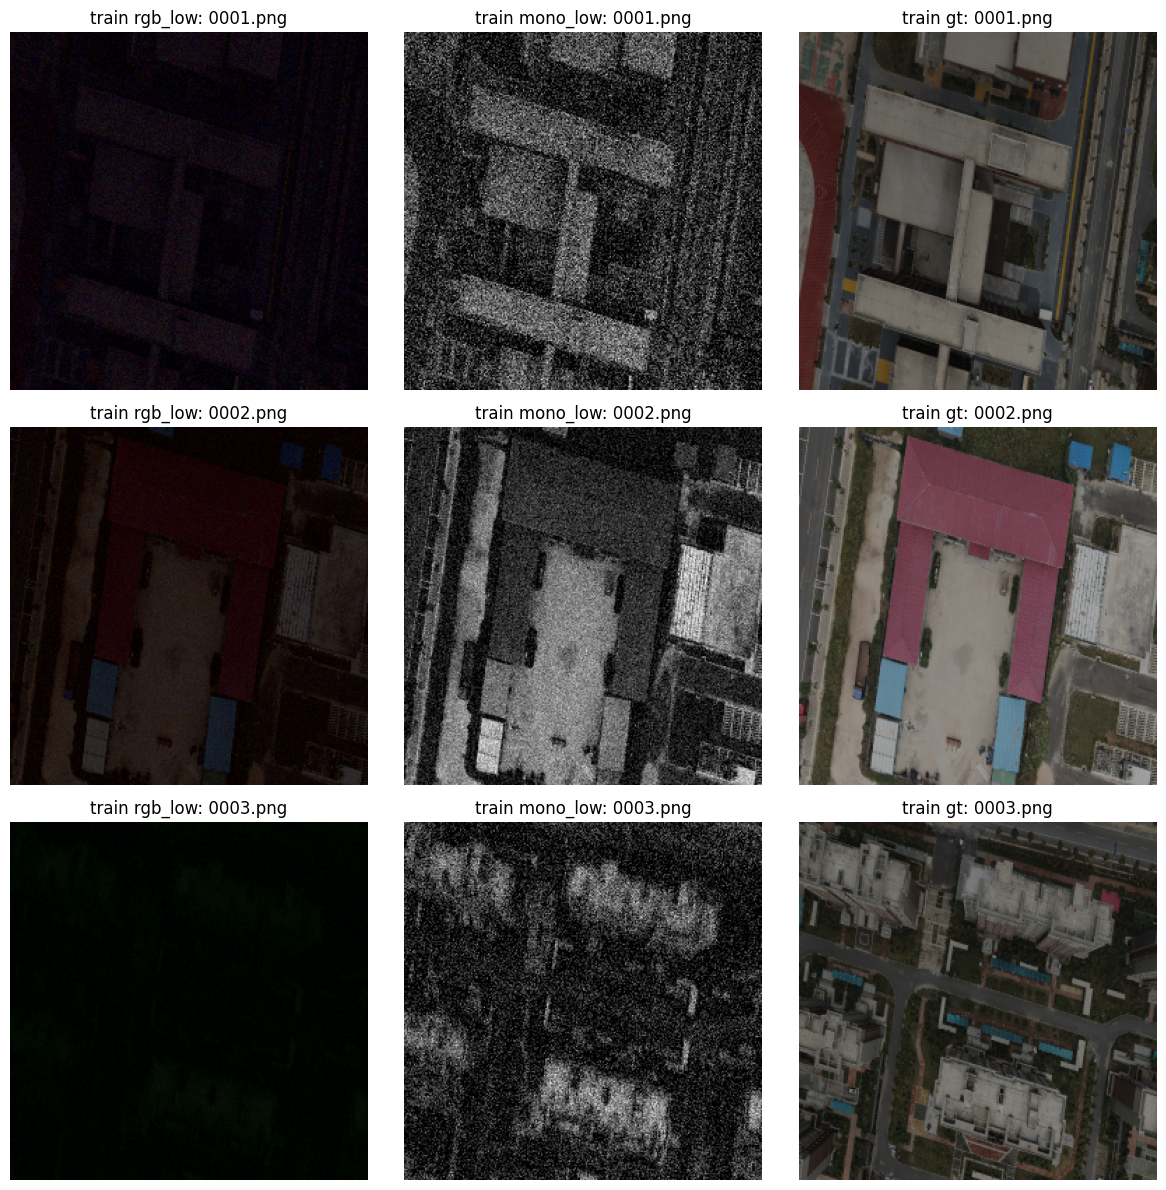

In [40]:
# 8. Visualization


def load_saved_rgb(path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def load_saved_mono(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return image


def visualize_samples(split: str = 'train', num_samples: int = 3) -> None:
    split_root = OUTPUT_ROOT / split
    file_names = sorted(path.name for path in (split_root / 'rgb_low').glob('*.png'))[:num_samples]
    if not file_names:
        raise RuntimeError(f'No saved samples found in {split_root}')

    fig, axes = plt.subplots(len(file_names), 3, figsize=(12, 4 * len(file_names)))
    if len(file_names) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, file_name in enumerate(file_names):
        rgb_low = load_saved_rgb(split_root / 'rgb_low' / file_name)
        mono_low = load_saved_mono(split_root / 'mono_low' / file_name)
        gt = load_saved_rgb(split_root / 'gt' / file_name)

        axes[row, 0].imshow(rgb_low)
        axes[row, 0].set_title(f'{split} rgb_low: {file_name}')
        axes[row, 1].imshow(mono_low, cmap='gray')
        axes[row, 1].set_title(f'{split} mono_low: {file_name}')
        axes[row, 2].imshow(gt)
        axes[row, 2].set_title(f'{split} gt: {file_name}')

        for col in range(3):
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()


visualize_samples(split='train', num_samples=3)